# q2_unsupervised.ipynb
### 1. Data Preparation 

In [1]:
!pip install matplotlib seaborn scikit-learn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# 1. Load Data
df = pd.read_csv('../data/q2_customers.csv')

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

### 2. Choosing K — Elbow Method

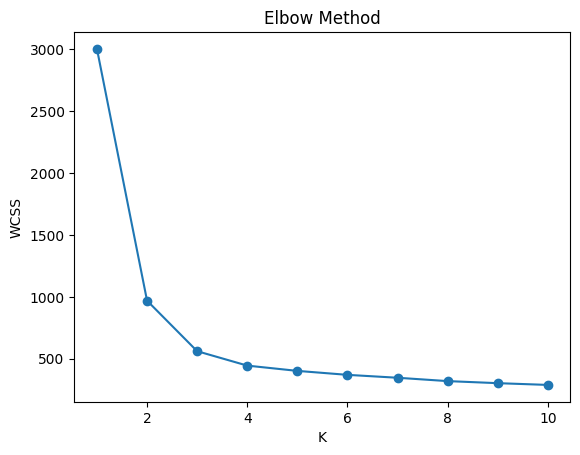

In [3]:
# 2. Elbow Method
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

### 3. K-Means Clustering

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
print(centroids)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


**Interpretation of Clusters:**

Based on the cluster centroids, we can interpret each customer segment in business terms as follows:

---

**Cluster 0: Young, High-Frequency, Moderate Spenders**

* Average age is relatively low (~25 years)
* Very high number of visits per month (~14 visits)
* Moderate annual spending (~14,800)
* Low days since last visit (~9 days)

**Business Insight:**
This cluster represents **young, highly engaged customers** who visit frequently but spend moderately per transaction. These are loyal and active customers who can be targeted with:

* Upselling strategies
* Membership or loyalty programs
* Personalized recommendations to increase basket size

---

**Cluster 1: Older, Infrequent but High-Value Customers**

* Highest average age (~56 years)
* Very low visit frequency (~2.5 visits/month)
* High annual spending (~89,000)
* Very high days since last visit (~105 days)

**Business Insight:**
This segment includes **high-value but inactive customers**. They spend a lot when they shop but visit rarely and may be at risk of churn.

* Ideal for re-engagement campaigns
* Personalized offers or reminders
* Premium or exclusive deals to bring them back

---

**Cluster 2: Middle-Aged, Moderate Frequency, Budget-Conscious Customers**

* age (~40 years)
* Moderate visits (~8 visits/month)
* Lower annual spending (~43,000)
* Moderate recency (~35 days)

**Business Insight:**
This group represents **average customers** with balanced behavior but lower spending levels.

* Target with discounts and promotions
* Encourage higher basket size
* Bundle offers to increase spending

---

**Overall Insight:**

The clustering reveals three distinct customer segments:

1. Highly engaged young shoppers
2. High-value but disengaged older customers
3. price-sensitive regular shoppers

This segmentation can help businesses design **targeted marketing strategies** instead of using a one-size-fits-all approach.


### 4. Dimensionality Reduction with PCA 

In [8]:
# 4. PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
print(loadings)


Explained Variance: [0.83560354 0.05568764]
        age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


**Interpretation of Principal Components:**

The PCA results show how the original features contribute to the new reduced dimensions (PC1 and PC2).

---

**Principal Component 1 (PC1): Overall Customer Engagement & Spending Behavior**

* High positive loadings:

  * annual_spend (~0.42)
  * basket_size (~0.41)
  * days_since_last_visit (~0.38)
* Negative loading:

  * visits_per_month (~ -0.41)

**Interpretation:**
PC1 captures a contrast between **high-spending, infrequent customers** and **frequent, lower-spending customers**.

* Customers with high PC1 scores:

  * Spend more per visit
  * Visit less frequently
  * Have larger basket sizes
* Customers with low PC1 scores:

  * Visit frequently
  * Spend less per transaction

This component essentially represents **customer value vs visit frequency trade-off**.

---

**Principal Component 2 (PC2): Recency and Visit Behavior**

* Strong positive loading:

  * days_since_last_visit (~0.91)
* Moderate positive:

  * visits_per_month (~0.21)
* Negative loadings:

  * age (~ -0.26)
  * basket_size (~ -0.20)

**Interpretation:**
PC2 is primarily driven by **recency (how recently a customer visited)**.

* Customers with high PC2 scores:

  * Have not visited for a long time (inactive customers)
* Customers with low PC2 scores:

  * Have visited more recently (active customers)

This component captures **customer activity level (active vs inactive)**.

---

**Overall Insight:**

* **PC1** differentiates customers based on **spending vs frequency**
* **PC2** differentiates customers based on **recency and engagement**

Together, these components allow us to visualize customer segments effectively in 2D space while preserving most of the important information (~89% variance explained).


C:\Users\Purnima Srivastava\AppData\Local\Temp\ipykernel_20556\604527990.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


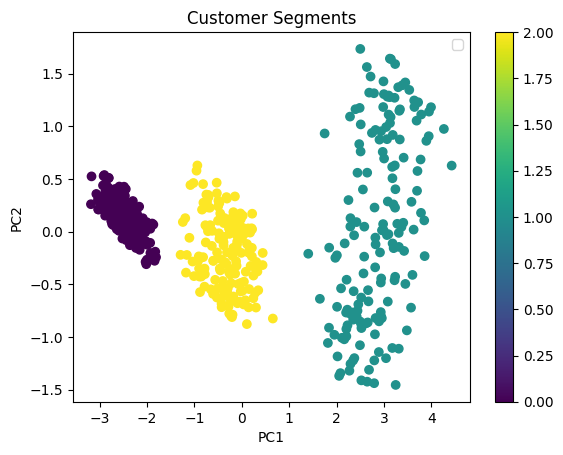

In [11]:
# 5. Visualization
plt.scatter(pca_data[:,0], pca_data[:,1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.colorbar()
plt.legend()
plt.show()